In [2]:
import os
import mne
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from collections import Counter

import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold

from mne_features.univariate import compute_higuchi_fd

# Calculate features

In [2]:
from mne.io import read_raw_edf

data_records = []

data_folder = '/mnt/s3-data2/amiftakhova/OCD/OCD/'
folders = [x for x in os.listdir(data_folder) if os.path.isdir(data_folder + x)]
inside_folders = []
for fldr in folders:
    ins = [fldr + '/' + x for x in os.listdir(data_folder + fldr) if os.path.isdir(data_folder + fldr + '/' + x)]
    if len(ins) > 0:
        inside_folders.extend(ins)
    else:
        inside_folders.append(fldr)
fldr2label = {inside_folders[i]: i for i in range(len(inside_folders))}

class2name = {0: 'anxiety', 1: 'bipolar', 2: 'control', 3: 'depression', 4: 'personality disorder', 5: 'stress', 6: 'ocd'}
name2class = {v: k for k, v in class2name.items()}

og_files = []
og_labels = []
for fldr in inside_folders:
    pth =  data_folder + fldr
    og_pths = [x for x in os.listdir(pth) if x.lower().endswith('.edf') and ('og.' in x.lower() or '_ог.' in x.lower() or ' ог.' in x.lower() or 'eo.' in x.lower() or '_eo' in x.lower() or '_of' in x.lower()) or '_оg' in x.lower()]
    for f in og_pths:
        og_files.append(pth + '/' + f)
        og_labels.append(fldr2label[fldr])

with open('../EEG_mh/split_multi_classes.json', encoding='utf-8') as f:
    split = json.load(f)

for i, fname in enumerate(og_files):
    fname_clr = fname.split('/')[-1][:-4]
    if fname_clr in split:
        file_split = split[fname_clr]['split']
        file_target = name2class[split[fname_clr]['target']]
        raw = read_raw_edf(fname, preload=True, verbose=False)
        signals = raw.get_data()  # Массив данных: shape (n_channels, n_times)
        channels2use = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'F7', 'F8', 'T3', 'T4', 'C3', 'Cz', 'C4', 'T5', 'T6', 'P3', 'Pz', 'P4', 'O1', 'O2']
        channel_names = raw.info['ch_names']
        new_channel_names = []
        for ch in channel_names:
            for ch2use in channels2use:
                if ch2use in ch:
                    new_channel_names.append(ch2use)
                    break
        channel_data = {name: signals[i, :].tolist() for i, name in enumerate(new_channel_names)}
        data_records.append({
            "patient_id": fname_clr,
            "label": split[fname_clr]['target'],
            "target": file_target,
            "file_path": fname,
            "sfreq": raw.info['sfreq'],  # Частота дискретизации
            "duration_sec": raw.n_times / raw.info['sfreq'],  # Длительность записи
            "n_channels": len(new_channel_names),  # Количество каналов
            "channels": channel_data  # Данные каналов
        })

df = pd.DataFrame(data_records)
df.head()

,patient_id,label,target,file_path,sfreq,duration_sec,n_channels,channels
0,ChMR_m37_f45-4_As_Ep_No_T_og,stress,5,/mnt/s3-data2/amiftakhova/OCD/OCD/Response to ...,250.0,23.0,19,"{'Fp1': [1.3069883573662944e-07, -1.4686749965..."
1,ChMR_m37_f45-4_f60-9_As_Ep_No_T_og,stress,5,/mnt/s3-data2/amiftakhova/OCD/OCD/Response to ...,250.0,23.0,19,"{'Fp1': [1.3069883573662944e-07, -1.4686749965..."
2,DrLu_f39_f45-9_Ep_og,stress,5,/mnt/s3-data2/amiftakhova/OCD/OCD/Response to ...,250.0,40.0,19,"{'Fp1': [-7.999974387731748e-06, -7.0962764690..."
3,FoMa_f32_f45-4_At_Ep_og,stress,5,/mnt/s3-data2/amiftakhova/OCD/OCD/Response to ...,250.0,45.0,19,"{'Fp1': [8.234806225680957e-07, 1.155197885099..."
4,GaAP_m19_f60-3_f42-8_f32-1_f45-2_Nr_As_og,ocd,6,/mnt/s3-data2/amiftakhova/OCD/OCD/Response to ...,250.0,43.0,19,"{'Fp1': [-3.229407465629053e-06, -3.5534688093..."


In [12]:
print(len(df))

383


In [17]:
df = df.drop(columns=['channels']).join(df['channels'].apply(pd.Series))

In [18]:
df.head()

,patient_id,label,target,file_path,sfreq,duration_sec,n_channels,Fp1,Fp2,F3,...,C3,Cz,C4,T5,T6,P3,Pz,P4,O1,O2
0,ChMR_m37_f45-4_As_Ep_No_T_og,stress,5,/mnt/s3-data2/amiftakhova/OCD/OCD/Response to ...,250.0,23.0,19,"[1.3069883573662944e-07, -1.4686749965667198e-...","[-1.0157847104600593e-06, -3.712834091706721e-...","[8.809437079423201e-07, -9.293443488212411e-07...",...,"[1.421560334172581e-06, 2.854875974670037e-07,...","[-6.518128542000471e-07, -2.6241560997940043e-...","[4.836742290379207e-07, -1.1091303166247024e-0...","[-1.3278260077820992e-06, -2.329835431448826e-...","[2.509308582589457e-06, 1.5580770074006261e-06...","[8.24405284199283e-07, 1.2932493095292594e-06,...","[2.0780237232013415e-06, 1.7955836942091995e-0...","[1.6059334782940416e-06, 8.639041870756087e-07...","[1.2735138612954925e-06, 4.163802201876861e-06...","[2.214024967574578e-06, 2.810129442282749e-06,..."
1,ChMR_m37_f45-4_f60-9_As_Ep_No_T_og,stress,5,/mnt/s3-data2/amiftakhova/OCD/OCD/Response to ...,250.0,23.0,19,"[1.3069883573662944e-07, -1.4686749965667198e-...","[-1.0157847104600593e-06, -3.712834091706721e-...","[8.809437079423201e-07, -9.293443488212411e-07...",...,"[1.421560334172581e-06, 2.854875974670037e-07,...","[-6.518128542000471e-07, -2.6241560997940043e-...","[4.836742290379207e-07, -1.1091303166247024e-0...","[-1.3278260077820992e-06, -2.329835431448826e-...","[2.509308582589457e-06, 1.5580770074006261e-06...","[8.24405284199283e-07, 1.2932493095292594e-06,...","[2.0780237232013415e-06, 1.7955836942091995e-0...","[1.6059334782940416e-06, 8.639041870756087e-07...","[1.2735138612954925e-06, 4.163802201876861e-06...","[2.214024967574578e-06, 2.810129442282749e-06,..."
2,DrLu_f39_f45-9_Ep_og,stress,5,/mnt/s3-data2/amiftakhova/OCD/OCD/Response to ...,250.0,40.0,19,"[-7.999974387731748e-06, -7.096276469062333e-0...","[-1.775384769970244e-06, -1.5141367421988242e-...","[-4.453944701304646e-06, -4.505788143739986e-0...",...,"[-3.2429271686884876e-06, -3.7961267426565964e...","[-2.5715102677958327e-06, -3.868168285648888e-...","[-2.704331065842678e-06, -3.5173204119935898e-...","[-2.907058648661019e-06, -3.875551590753031e-0...","[-1.0085478452735177e-06, -1.8156959176012813e...","[-3.4191597103837648e-06, -3.960457513389792e-...","[-4.0113743358510725e-06, -4.403468842603189e-...","[-2.4644780285343704e-06, -3.437428378728923e-...","[-2.9644163936827645e-06, -3.639696986953536e-...","[-1.4086361867704295e-06, -2.2303918287937756e..."
3,FoMa_f32_f45-4_At_Ep_og,stress,5,/mnt/s3-data2/amiftakhova/OCD/OCD/Response to ...,250.0,45.0,19,"[8.234806225680957e-07, 1.1551978850995677e-06...","[9.95671778439009e-08, 1.3678004501411464e-06,...","[9.811744136720845e-07, 8.583367620355544e-07,...",...,"[-1.6872583398184203e-06, -1.8974820492866432e...","[-2.2463270618753128e-07, -7.042579262989221e-...","[7.529759685664143e-07, 8.50658797589074e-07, ...","[-1.6814164065003459e-06, -2.3960353032730625e...","[-1.1548972579537647e-06, -1.1832738963912406e...","[-1.7114091935606948e-06, -2.440014183260855e-...","[-1.1019583474479296e-06, -2.2055295628290235e...","[9.92487846189076e-08, 1.1152135042343952e-07,...","[-2.6383339940489815e-06, -4.22604469672694e-0...","[-2.64393179217212e-06, -2.9412755199511696e-0..."
4,GaAP_m19_f60-3_f42-8_f32-1_f45-2_Nr_As_og,ocd,6,/mnt/s3-data2/amiftakhova/OCD/OCD/Response to ...,250.0,43.0,19,"[-3.229407465629053e-06, -3.553468809338521e-0...","[1.041653641565578e-06, 2.923348134584813e-08,...","[-3.8082352147707317e-06, -3.4872715739681067e...",...,"[-2.4015239765011068e-06, -1.809848560311285e-...","[-2.371742430762187e-06, -1.7537817212176687e-...","[-1.822385236896314e-06, -1.4368707179369795e-...","[-3.5130228015564186e-06, -3.2762892607003877e...","[-1.3653659327077134e-06, -5.924365117875943e-...","[-4.8429386358434435e-06, -4.940336850537882e-...","[-4.1637187319752804e-06, -3.6918015579461362e...","[-2.974767026779582e-06, -2.541681341268023e-0...","[-2.9591232089723045e-06, -2.450064080262455e-...","[-8.83336009765775

In [20]:
import numpy as np
import pandas as pd
from scipy.signal import welch, hilbert
from scipy.stats import pearsonr, entropy
from mne_connectivity import SpectralConnectivity
from mne.time_frequency import psd_array_welch
from scipy import signal
from itertools import combinations
from joblib import Parallel, delayed
from scipy.linalg import svd
import antropy as ant
from nolds import dfa, lyap_r, hurst_rs
import random

import numpy as np
from scipy.signal import welch, hilbert, filtfilt, firwin
from scipy.stats import pearsonr, entropy
from scipy.spatial.distance import pdist, squareform
from numpy.linalg import lstsq
import antropy as ant
from nolds import dfa, hurst_rs
import warnings

band_bounds = {
    'theta': [4, 8],
    'alpha': [8, 13],
    'beta': [13, 30],
    'gamma': [30, 45]
}


random.seed(42)
np.random.seed(42)

sfreq = 250
# Precompute filters for each band
filters = {
    band: signal.firwin2(
        numtaps=251,
        freq=[0, max(0, low - 1), low, high, high + 1, sfreq / 2],
        gain=[0, 0, 1, 1, 0, 0],
        fs=sfreq
    )
    for band, (low, high) in band_bounds.items()
}


def compute_band_power(signal_array, sfreq, band_bounds):
    """Compute power for all bands in a single pass."""
    freqs, psd = welch(signal_array, fs=sfreq, nperseg=min(256, len(signal_array)))
    total_power = psd.sum()
    band_powers = {band: psd[(freqs >= low) & (freqs <= high)].sum() / total_power
                   for band, (low, high) in band_bounds.items()}
    return band_powers


def compute_envelope_features(signal_array, filt, band):
    """Compute envelope standard deviation and correlation."""
    filtered_signal = np.convolve(filt, signal_array, 'valid')
    envelope = np.abs(hilbert(filtered_signal))
    std_ratio = envelope.std() / envelope.mean() if envelope.mean() > 0 else 0
    return std_ratio, envelope


def compute_non_linear_features(signal_array, sfreq):
    """Compute non-linear features for the signal."""
    sanitized_signal = np.array(signal_array, dtype=np.float64)
    sanitized_signal = sanitized_signal[np.isfinite(sanitized_signal)]  # Remove NaN/Inf
    if len(sanitized_signal) < 10:
        return {key: np.nan for key in [
            'approx_entropy', 'sample_entropy', 'spectral_entropy', 'higuchi_fd',
            'dfa','hurst_exp', 'diagonal_entropy', 'fisher_info', 'lyap_exp'
        ]}

    non_linear_feats = {}

    # (a) Entropy measures
    non_linear_feats['approx_entropy'] = ant.app_entropy(sanitized_signal)
    non_linear_feats['sample_entropy'] = ant.sample_entropy(sanitized_signal)
    non_linear_feats['spectral_entropy'] = ant.spectral_entropy(sanitized_signal, sfreq, method='welch')

    # (b) Fractal dimensions
    non_linear_feats['higuchi_fd'] = ant.higuchi_fd(sanitized_signal)

    # (c) DFA (Detrended Fluctuation Analysis)
    non_linear_feats['dfa'] = dfa(sanitized_signal)

    # (e) Hurst exponent
    non_linear_feats['hurst_exp'] = hurst_rs(sanitized_signal)

    # (g) Recurrence analysis features
    recurrence_matrix = np.abs(sanitized_signal[:, None] - sanitized_signal) < 0.1  # Threshold example
    diagonal_lengths = [np.sum(np.diag(recurrence_matrix, k)) for k in range(-len(sanitized_signal), len(sanitized_signal))]
    non_linear_feats['diagonal_entropy'] = entropy(diagonal_lengths)

    # (h) Chaos measures
    non_linear_feats['fisher_info'] = np.var(sanitized_signal) / np.mean(sanitized_signal**2)

    return non_linear_feats

def extract_features(row, channels, sfreq):
    """Extract features for a single row."""
    feats = {'patient_id': row['patient_id'], 'label': row['label'], 'target': row['target']}
    channel_data = {ch: row[ch] for ch in channels if isinstance(row[ch], list) and len(row[ch]) > 0}
    channel_signals = np.array(list(channel_data.values()))

    # Compute band power
    for idx, channel in enumerate(channel_data):
        band_powers = compute_band_power(channel_signals[idx], sfreq, band_bounds)
        for band, power in band_powers.items():
            feats[f'{channel}_{band}_power'] = power

    # Compute envelope features
    for band, filt in filters.items():
        envelopes = []
        for idx, signal_array in enumerate(channel_signals):
            std_ratio, envelope = compute_envelope_features(signal_array, filt, band)
            feats[f'{list(channel_data.keys())[idx]}_env_std_{band}'] = std_ratio
            envelopes.append(envelope)

        # Compute envelope correlations
        for i, j in combinations(range(len(envelopes)), 2):
            ch1 = list(channel_data.keys())[i]
            ch2 = list(channel_data.keys())[j]
            feats[f'env_corr_{ch1}_{ch2}_{band}'] = pearsonr(envelopes[i], envelopes[j])[0]

    # Compute non-linear features
    for idx, signal_array in enumerate(channel_signals):
        non_linear_feats = compute_non_linear_features(signal_array, sfreq)
        for feat_name, feat_value in non_linear_feats.items():
            feats[f'{list(channel_data.keys())[idx]}_{feat_name}'] = feat_value

    return feats

# Extract features for all rows in parallel
channels = ['C3', 'C4', 'Cz', 'F3', 'F4', 'F7', 'F8', 'Fp2', 'Fz', 'P3', 'P4', 'Pz', 'T3', 'T4']
sfreq = 250.  # Replace with actual sampling frequency if variable
all_feats = Parallel(n_jobs=-1)(delayed(extract_features)(row, channels, sfreq) for _, row in df.iterrows())

# Create a DataFrame with extracted features
feats_df = pd.DataFrame(all_feats)

/media/ssd-3t/amiftakhova/conda/eeg-venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/media/ssd-3t/amiftakhova/conda/eeg-venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/media/ssd-3t/amiftakhova/conda/eeg-venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/media/ssd-3t/amiftakhova/conda/eeg-venv/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/media/ssd-3t/amiftakhova/conda/eeg-venv/lib/python3.11/site-pac

In [21]:
feats_df.head()

,patient_id,label,target,C3_theta_power,C3_alpha_power,C3_beta_power,C3_gamma_power,C4_theta_power,C4_alpha_power,C4_beta_power,...,T3_diagonal_entropy,T3_fisher_info,T4_approx_entropy,T4_sample_entropy,T4_spectral_entropy,T4_higuchi_fd,T4_dfa,T4_hurst_exp,T4_diagonal_entropy,T4_fisher_info
0,ChMR_m37_f45-4_As_Ep_No_T_og,stress,5,0.210286,0.233184,0.313972,0.049104,0.205921,0.214847,0.330304,...,9.156955,0.985599,0.712005,0.661981,4.923258,1.446387,0.935088,0.603977,9.156955,0.982005
1,ChMR_m37_f45-4_f60-9_As_Ep_No_T_og,stress,5,0.210286,0.233184,0.313972,0.049104,0.205921,0.214847,0.330304,...,9.156955,0.985599,0.712005,0.661981,4.923258,1.446387,0.935088,0.603977,9.156955,0.982005
2,DrLu_f39_f45-9_Ep_og,stress,5,0.189218,0.136475,0.374686,0.054221,0.174453,0.141469,0.381570,...,9.710340,0.999802,0.906393,0.870785,5.228114,1.549469,0.579329,0.593933,9.710340,0.998652
3,FoMa_f32_f45-4_At_Ep_og,stress,5,0.205380,0.196373,0.374643,0.025476,0.181179,0.190167,0.358325,...,9.828123,0.997070,0.841755,0.795692,5.039500,1.471568,0.831420,0.604900,9.828123,0.996138
4,GaAP_m19_f60-3_f42-8_f32-1_f45-2_Nr_As_og,ocd,6,0.137714,0.408252,0.197847,0.023998,0.144625,0.222909,0.275651,...,9.782661,0.993575,0.745981,0.717734,4.602798,1.443677,0.919981,0.681734,9.782661,0.996610


In [22]:
feats_df.to_csv("features_open_refined.csv", index=False)

In [3]:
feats_df = pd.read_csv("features_open_refined.csv")

# Try to cluster and colour

In [34]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# feature_cols = [c for c in feats_df.columns if c not in ["patient_id", "label", "target"]]
feature_cols = ['env_corr_F7_T3_theta', 'env_corr_F8_T4_theta', 'F3_diagonal_entropy', 'C4_diagonal_entropy', 'Pz_diagonal_entropy',
                'Fz_diagonal_entropy', 'Fp2_diagonal_entropy', 'C3_diagonal_entropy', 'F7_diagonal_entropy', 'T3_diagonal_entropy']
X = feats_df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
db = KMeans(n_clusters=7)
clusters = db.fit_predict(X_scaled)

In [26]:
clusters

array([6, 6, 3, 3, 4, 0, 3, 3, 3, 3, 4, 4, 3, 1, 1, 4, 4, 3, 1, 3, 3, 3,
       3, 6, 3, 3, 3, 3, 4, 4, 4, 4, 4, 3, 1, 4, 1, 3, 3, 4, 3, 3, 1, 4,
       4, 4, 4, 3, 3, 4, 3, 4, 0, 4, 3, 4, 4, 1, 0, 6, 4, 0, 3, 1, 3, 3,
       6, 3, 3, 1, 3, 3, 3, 3, 1, 0, 3, 1, 3, 1, 4, 4, 4, 3, 3, 3, 3, 4,
       3, 1, 4, 4, 4, 4, 3, 5, 1, 3, 4, 3, 3, 1, 3, 4, 3, 6, 4, 5, 5, 4,
       4, 1, 1, 3, 4, 0, 3, 0, 1, 1, 4, 3, 4, 4, 1, 3, 5, 3, 3, 4, 3, 3,
       0, 4, 4, 4, 1, 5, 3, 6, 4, 4, 4, 3, 3, 5, 5, 5, 5, 5, 5, 1, 1, 3,
       5, 0, 5, 3, 2, 2, 4, 0, 2, 2, 0, 3, 5, 2, 2, 5, 4, 0, 0, 3, 5, 5,
       4, 3, 0, 5, 5, 5, 5, 2, 1, 3, 5, 4, 2, 0, 2, 3, 5, 5, 3, 4, 4, 2,
       4, 3, 3, 4, 6, 3, 1, 4, 0, 4, 3, 4, 1, 3, 4, 5, 4, 3, 3, 6, 3, 3,
       3, 3, 4, 3, 1, 4, 3, 4, 4, 3, 4, 0, 0, 4, 3, 6, 1, 3, 3, 5, 4, 4,
       3, 3, 4, 4, 1, 0, 3, 6, 3, 3, 6, 4, 3, 3, 1, 3, 5, 3, 3, 3, 6, 3,
       6, 3, 6, 1, 3, 3, 4, 4, 4, 4, 4, 6, 3, 3, 4, 6, 6, 6, 3, 3, 3, 2,
       3, 3, 0, 0, 0, 0, 3, 5, 0, 6, 2, 2, 3, 2, 0,

In [27]:
feats_df["cluster"] = clusters

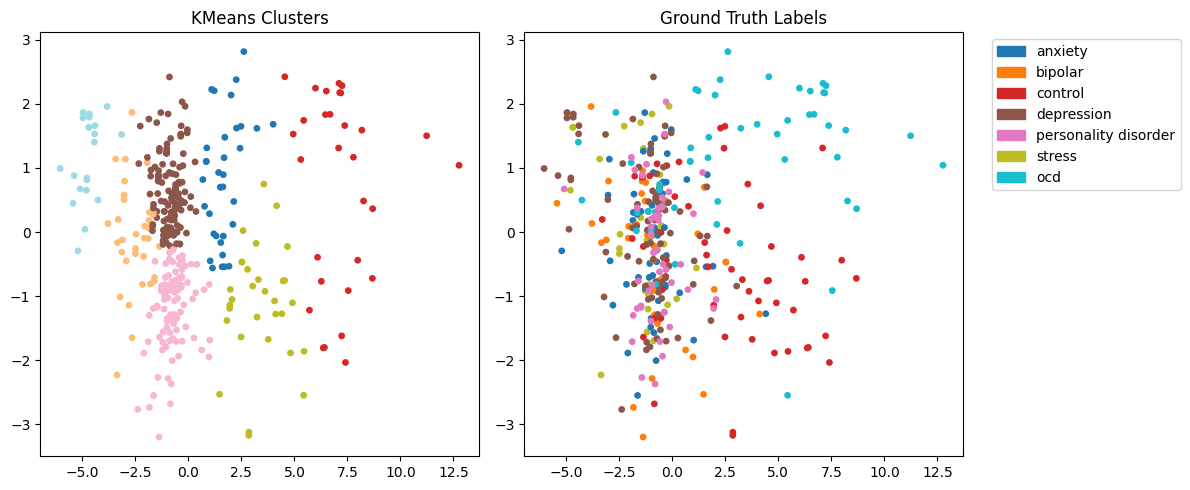

In [33]:
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

class2name = {0: 'anxiety', 1: 'bipolar', 2: 'control', 3: 'depression', 4: 'personality disorder', 5: 'stress', 6: 'ocd'}

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_2d[:,0], X_2d[:,1], c=feats_df["cluster"], cmap="tab20", s=15)
plt.title("KMeans Clusters")

plt.subplot(1,2,2)
scatter2 = plt.scatter(X_2d[:,0], X_2d[:,1], c=feats_df["target"], cmap="tab10", s=15)
plt.title("Ground Truth Labels")
unique_labels = np.unique(feats_df["target"])
label_patches = [mpatches.Patch(color=scatter2.cmap(scatter2.norm(val)), 
                                label=f"{class2name[int(val)]}") for val in unique_labels]
plt.legend(handles=label_patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

In [48]:
db = DBSCAN(eps=0.7)
clusters = db.fit_predict(X_scaled)
clusters

array([ 0,  0,  1,  1,  1,  3,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
       -1,  1,  1,  1,  1,  1,  2,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  3, -1,  1,  4,  1,  1,  1,  1,  0,  1,
        1,  1,  1,  1,  1,  1,  1,  6,  1, -1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1,  1, -1,
        1,  1,  1, -1,  1,  3, -1,  1,  1, -1,  1,  1, -1,  6,  1, -1,  1,
       -1,  1,  1, -1, -1,  1,  1,  3,  1,  1,  1,  1,  1,  6,  1,  1,  1,
       -1, -1,  1,  2,  1,  1,  1,  1,  1, -1,  3, -1, -1, -1, -1,  1,  1,
        1, -1,  3, -1,  1,  5, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        1, -1, -1,  1, -1, -1,  1,  1,  4, -1, -1, -1, -1, -1, -1,  1, -1,
       -1, -1,  3, -1,  1, -1, -1, -1,  1,  1, -1,  1,  1, -1,  1, -1,  1,
       -1,  1,  3,  1,  1,  1,  1,  1,  1,  3,  1,  1,  1,  0,  1,  1,  1,
       -1,  1,  1,  1, -1

In [49]:
feats_df["cluster_dbscan"] = clusters

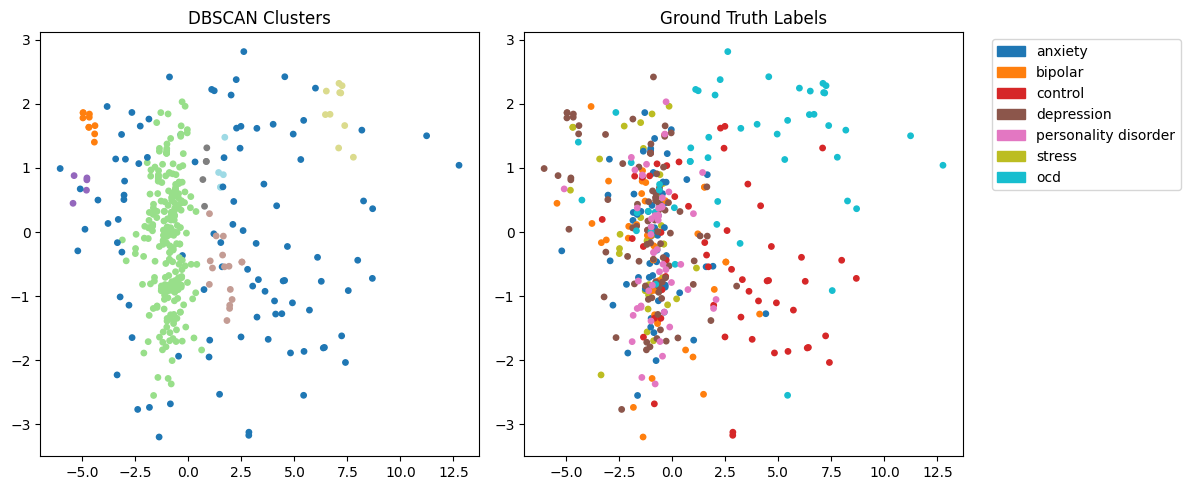

In [50]:
class2name = {0: 'anxiety', 1: 'bipolar', 2: 'control', 3: 'depression', 4: 'personality disorder', 5: 'stress', 6: 'ocd'}

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_2d[:,0], X_2d[:,1], c=feats_df["cluster_dbscan"], cmap="tab20", s=15)
plt.title("DBSCAN Clusters")

plt.subplot(1,2,2)
scatter2 = plt.scatter(X_2d[:,0], X_2d[:,1], c=feats_df["target"], cmap="tab10", s=15)
plt.title("Ground Truth Labels")
unique_labels = np.unique(feats_df["target"])
label_patches = [mpatches.Patch(color=scatter2.cmap(scatter2.norm(val)), 
                                label=f"{class2name[int(val)]}") for val in unique_labels]
plt.legend(handles=label_patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

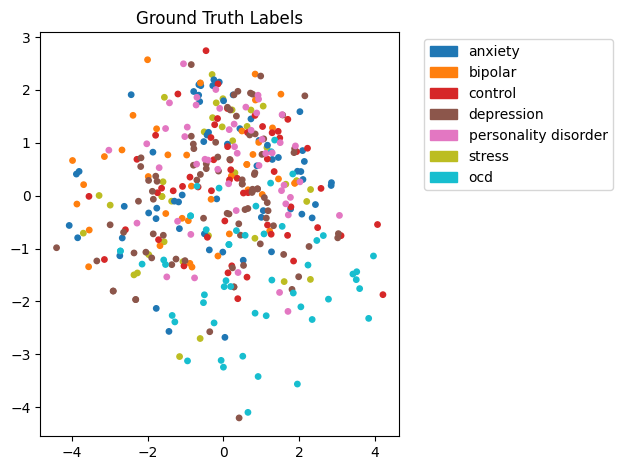

In [51]:
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

class2name = {0: 'anxiety', 1: 'bipolar', 2: 'control', 3: 'depression', 4: 'personality disorder', 5: 'stress', 6: 'ocd'}

feature_cols = ['env_corr_F7_T3_theta', 'env_corr_F4_Fp2_gamma', 'env_corr_Fp2_T4_alpha', 'env_corr_F8_T4_gamma', 'env_corr_Cz_Pz_gamma',
                'env_corr_Fz_T3_alpha', 'env_corr_F4_Fp2_beta', 'env_corr_Cz_T4_theta', 'F3_spectral_entropy', 'env_corr_F3_Fz_gamma']
X = feats_df[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

scatter2 = plt.scatter(X_2d[:,0], X_2d[:,1], c=feats_df["target"], cmap="tab10", s=15)
plt.title("Ground Truth Labels")
unique_labels = np.unique(feats_df["target"])
label_patches = [mpatches.Patch(color=scatter2.cmap(scatter2.norm(val)), 
                                label=f"{class2name[int(val)]}") for val in unique_labels]
plt.legend(handles=label_patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

# Random forest on top features

In [5]:
import json

with open('../../spectrograms/split_multi_classes.json', encoding='utf-8') as f:
    split = json.load(f)

In [6]:
split_col = [split[row['patient_id']]['split'] for _, row in feats_df.iterrows()]
feats_df['split'] = split_col

In [7]:
feats_df['split']

0      train
1       test
2        val
3        val
4       test
       ...  
378    train
379    train
380      val
381    train
382      val
Name: split, Length: 383, dtype: object

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

feature_cols = [c for c in feats_df.columns if c not in ["patient_id", "label", "target", "split"]]
# feature_cols = ['env_corr_F7_T3_theta', 'env_corr_F8_T4_theta', 'F3_diagonal_entropy', 'C4_diagonal_entropy', 'Pz_diagonal_entropy',
#                 'Fz_diagonal_entropy', 'Fp2_diagonal_entropy', 'C3_diagonal_entropy', 'F7_diagonal_entropy', 'T3_diagonal_entropy']
df_train = feats_df[feats_df["split"] == "train"]
df_test = feats_df[feats_df["split"] == "test"]

X_train = df_train[feature_cols].values
y_train = df_train["target"].values
X_test = df_test[feature_cols].values
y_test = df_test["target"].values

clf = RandomForestClassifier(class_weight="balanced", random_state=42)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

print(f1_score(y_test, preds, average="macro"))

0.30434635392618586


In [11]:
import numpy as np
import pandas as pd
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score

# Фиксируем случайное состояние для воспроизводимости
random.seed(42)
np.random.seed(42)

# 1. Разбивка данных на train+validation и test (80% и 20% соответственно)
#X_train_val, X_test, y_train_val, y_test = train_test_split(
#    X, y, test_size=0.2, stratify=y, random_state=42
#)

# 2. Из train+validation выделяем отдельную валидационную выборку (25% от train_val)
#X_train, X_val, y_train, y_val = train_test_split(
#    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
#)
feature_cols = [c for c in feats_df.columns if c not in ["patient_id", "label", "target", "split"]]
df_train = feats_df[feats_df["split"] == "train"]
df_val = feats_df[feats_df["split"] == "val"]
df_test = feats_df[feats_df["split"] == "test"]
X_train = df_train[feature_cols].values
y_train = df_train["target"].values
X_val = df_val[feature_cols].values
y_val = df_val["target"].values
X_test = df_test[feature_cols].values
y_test = df_test["target"].values


# 3. Инициализация моделей
models = {
    "RandomForest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "LogisticRegression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "SVM": SVC(class_weight="balanced", probability=True, random_state=42),
    "SVM_RBF": SVC(kernel='rbf', class_weight="balanced", probability=True, random_state=42)
}

# 4. Кросс-валидация на обучающей выборке
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
feature_importances = {}

# Получаем имена признаков
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns
else:
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

# Базовая модель: предсказание наиболее часто встречающегося класса
f1_baseline_scores = []
for train_idx, test_idx in skf.split(X_train, y_train):
    y_train_cv = y_train.iloc[train_idx] if hasattr(y_train, 'iloc') else y_train[train_idx]
    y_test_cv = y_train.iloc[test_idx] if hasattr(y_train, 'iloc') else y_train[test_idx]
    most_common_class = pd.Series(y_train_cv).value_counts().idxmax()
    y_pred_baseline = np.full_like(y_test_cv, most_common_class)
    f1 = f1_score(y_test_cv, y_pred_baseline, average="macro")
    f1_baseline_scores.append(f1)
results["MostCommon"] = {
    "mean": np.mean(f1_baseline_scores),
    "std": np.std(f1_baseline_scores)
}

# 5. Кросс-валидация для оценки моделей и сбора важностей признаков
for model_name, model in models.items():
    f1_scores_cv = []
    importances_list = []
    for train_idx, test_idx in skf.split(X_train, y_train):
        X_train_cv = X_train.iloc[train_idx] if hasattr(X_train, 'iloc') else X_train[train_idx]
        X_test_cv = X_train.iloc[test_idx] if hasattr(X_train, 'iloc') else X_train[test_idx]
        y_train_cv = y_train.iloc[train_idx] if hasattr(y_train, 'iloc') else y_train[train_idx]
        y_test_cv = y_train.iloc[test_idx] if hasattr(y_train, 'iloc') else y_train[test_idx]
        model.fit(X_train_cv, y_train_cv)
        y_pred = model.predict(X_test_cv)
        f1 = f1_score(y_test_cv, y_pred, average="macro")
        f1_scores_cv.append(f1)
        # Важности признаков
        if hasattr(model, 'feature_importances_'):
            importances_list.append(model.feature_importances_)
        elif hasattr(model, 'coef_'):
            # Для мультикласса: среднее по классам
            importances_list.append(np.abs(model.coef_).mean(axis=0))
    results[model_name] = {
        "mean": np.mean(f1_scores_cv),
        "std": np.std(f1_scores_cv)
    }
    if importances_list:
        feature_importances[model_name] = np.mean(importances_list, axis=0)

# 6. Вывод результатов моделей (оценка на обучении через CV)
print("\nModel Results on Training Set (via CV):")
for model_name, metrics in results.items():
    print(f"{model_name}: {metrics['mean']:.4f} ± {metrics['std']:.4f}")

# 7. Оценка моделей на валидационной выборке
print("\nValidation Set Evaluation:")
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    f1_val = f1_score(y_val, y_val_pred, average="macro")
    print(f"{model_name} on validation: F1 = {f1_val:.4f}")

# 8. Финальная оценка на тестовой выборке
print("\nTest Set Evaluation:")
for model_name, model in models.items():
    model.fit(np.concat([X_train, X_val]), np.concat([y_train, y_val]))
    y_test_pred = model.predict(X_test)
    f1_test = f1_score(y_test, y_test_pred, average="macro")
    print(f"{model_name} on test: F1 = {f1_test:.4f}")

# 9. Анализ топ-N признаков по важности для каждой модели (на основе CV)
top_n = 10
for model_name, importances in feature_importances.items():
    print(f"\nTop {top_n} features for {model_name}:")
    sorted_indices = np.argsort(importances)[::-1][:top_n]
    for idx in sorted_indices:
        print(f"{feature_names[idx]}: {importances[idx]:.4f}")



Model Results on Training Set (via CV):
MostCommon: 0.0514 ± 0.0005
RandomForest: 0.4431 ± 0.0633
LogisticRegression: 0.3385 ± 0.0872
SVM: 0.0595 ± 0.0476
SVM_RBF: 0.0595 ± 0.0476

Validation Set Evaluation:
RandomForest on validation: F1 = 0.2918
LogisticRegression on validation: F1 = 0.2879
SVM on validation: F1 = 0.0560
SVM_RBF on validation: F1 = 0.0560

Test Set Evaluation:
RandomForest on test: F1 = 0.3262
LogisticRegression on test: F1 = 0.3054
SVM on test: F1 = 0.0361
SVM_RBF on test: F1 = 0.0361

Top 10 features for RandomForest:
feature_131: 0.0094
feature_506: 0.0093
feature_490: 0.0089
feature_236: 0.0086
feature_538: 0.0078
feature_570: 0.0076
feature_546: 0.0075
feature_139: 0.0073
feature_554: 0.0070
feature_578: 0.0062

Top 10 features for LogisticRegression:
feature_433: 0.3698
feature_534: 0.2968
feature_582: 0.2857
feature_103: 0.2729
feature_414: 0.2691
feature_139: 0.2686
feature_341: 0.2635
feature_131: 0.2573
feature_219: 0.2572
feature_478: 0.2571
